# Spot-Size Super-Resolution Benchmark

**Purpose.** Compare TESLA, iStar, Spotify, and REVISE super-resolution reconstruction across parts 1–3 and spot sizes 50, 100, 150, and 200.

**Inputs.** Use the Sim2Real-ST spot H5AD files and the per-gene PCC, SSIM, and MSE tables under `results/spot_sr_baseline/`. Historical method IDs map as 1 = TESLA, 3 = iStar, 2 = Spotify, and 4 = REVISE.

### Two ways to obtain the analysis inputs

1. **Reconstruct locally.** Download the Sim2Real-ST inputs and complete the TESLA, iStar, Spotify, and REVISE workflows for every configured part and spot size, writing their metric tables to the configured result tree.
2. **Start from released results.** Download [`Sim2Real-ST.zip` and `Result.zip`](https://zenodo.org/records/17705737), then place the extracted files under the raw-data and result directories declared in the configuration section.

All four methods must be available before the comparison cells are run.

After completing either path, run this notebook from top to bottom.

## 1. Configuration and method mapping

Define repository paths, fixed spot sizes, metrics, and the mapping from historical directory IDs to method names.

In [9]:
# [CONFIG] Repository and output paths
import os

source_path = "../.."
output_dir = f"{source_path}/output/spot_benchmark"
os.makedirs(output_dir, exist_ok=True)

In [10]:
# [CONFIG] Benchmark cases and method labels
task = "spot_sr_baseline"
result_path = f"{source_path}/results/{task}"
data_path = f"{source_path}/raw_data/Sim2Real-ST/spot"

methods = [1, 3, 2, 4]
method_labels = {
    1: "TESLA",
    3: "iStar",
    2: "Spotify",
    4: "REVISE",
}

parts = ["part3", "part1", "part2"]
metrics = ["PCC", "SSIM", "MSE"]
spot_sizes = [50, 100, 150, 200]

## 2. Gene selection and metric loading

Select the configured genes and assemble method-labelled metric values while retaining numeric IDs only for historical file paths.

In [11]:
# [DEFINE] Gene-selection and metric-loading helpers
import os
import pandas as pd
import scanpy as sc
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

def get_genes(result_path, data_path, part, spot_size, method, gene_type = "HVG", gene_num = 50, test_genes = None): 
    # Select HVG, HEG, or all genes.
    spot_path = os.path.join(data_path, f"{part}", f"spot_{spot_size}")
    save_path = os.path.join(result_path, part, f"{spot_size}_{method}", "select_gene")
    os.makedirs(save_path, exist_ok=True)

    gene_file = f"{save_path}/{gene_type}_genes_{gene_num}.txt"
    if os.path.exists(gene_file):
        # print(f"Find {gene_type} genes in {gene_file}")
        with open(gene_file, "r") as f:
            genes = f.read().splitlines()
        return genes

    st_path = f"{spot_path}/xenium_spot.h5ad"
    adata = sc.read(st_path)
    if test_genes is not None:
        overlap_genes = [gene for gene in test_genes if gene in adata.var_names]
        adata = adata[:, overlap_genes]
    
    if gene_type == "HVG":
        sc.pp.filter_genes(adata, min_cells=1)
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=gene_num)
        genes = adata.var[adata.var['highly_variable']].index.tolist()
    elif gene_type == "HEG":
        adata.var['sum'] = adata.X.toarray().sum(axis=0)
        adata.var.sort_values('sum', ascending=True, inplace=True)
        genes = adata.var.head(gene_num).index.tolist()
    else:
        genes = adata.var_names
    
    with open(gene_file, "w") as f:
        f.write("\n".join(genes))
    # print(f"Save {gene_type} genes to {gene_file}")

    return genes

def get_merge_df(result_path, data_path, part, metric, spot_sizes, methods):

    merge_df = pd.DataFrame()
    for spot_size in tqdm(spot_sizes, desc="spot_sizes"):  
        for method in methods:
            metric_file = f"{result_path}/{part}/{spot_size}_{method}/metrics_normalized.csv"
            df = pd.read_csv(metric_file, index_col=0)
            genes = get_genes(result_path, data_path, part, spot_size, method, gene_type = gene_type, gene_num = gene_num, test_genes = df.index)
            df = df.loc[genes]
            
            df = pd.DataFrame({
                'Method': method_labels[method],
                'Value': df[metric].values,
                'Spot_size': spot_size,
                'Part': part,
                'Metric': metric,
            })
        
            merge_df = pd.concat([merge_df, df])
    merge_df.reset_index(drop=True, inplace=True)
    return merge_df

## 3. Highly variable genes

Compute mean metrics and visualize the four reconstruction methods using the selected HVGs.

In [12]:
# [CONFIG] Highly variable genes
gene_type = "HVG"
gene_num = 50

In [13]:
# [RUN] Compute and save mean HVG metrics
parts = ["part3", "part1", "part2"]
metrics = ["PCC", "SSIM", "MSE"]
spot_sizes = [50, 100, 150, 200]

# spot_sizes = [50]
# part = parts[0]
save_dir = f"{output_dir}/{gene_type}_mean"
os.makedirs(save_dir, exist_ok=True)
for part in tqdm(parts, desc="parts"):
    for spot_size in tqdm(spot_sizes, desc="spot_sizes"):  
        merge_df = pd.DataFrame()
        for method in methods:
            metric_file = f"{result_path}/{part}/{spot_size}_{method}/metrics_normalized.csv"
            df = pd.read_csv(metric_file, index_col=0)
            genes = get_genes(result_path, data_path, part, spot_size, method, gene_type = gene_type, gene_num = gene_num, test_genes = df.index)
            df = df.loc[genes]
            
            df = df[metrics].mean(axis=0)
        
            merge_df = pd.concat([merge_df, df], axis=1)
        merge_df.reset_index(drop=True, inplace=True)
        merge_df.index = metrics
        merge_df.columns = [method_labels[method] for method in methods]
        merge_df.T.to_csv(f"{save_dir}/{part}_{spot_size}_{gene_type}_{gene_num}.csv")

print(f"Saved final metric tables to {save_dir}")


parts: 100%|██████████| 3/3 [00:00<00:00, 15.14it/s]

Saved final metric tables to ../../output/spot_benchmark/HVG_mean


spot_sizes:   0%|          | 0/4 [00:00<?, ?it/s]

spot_sizes: 100%|██████████| 4/4 [00:00<00:00, 235.60it/s]


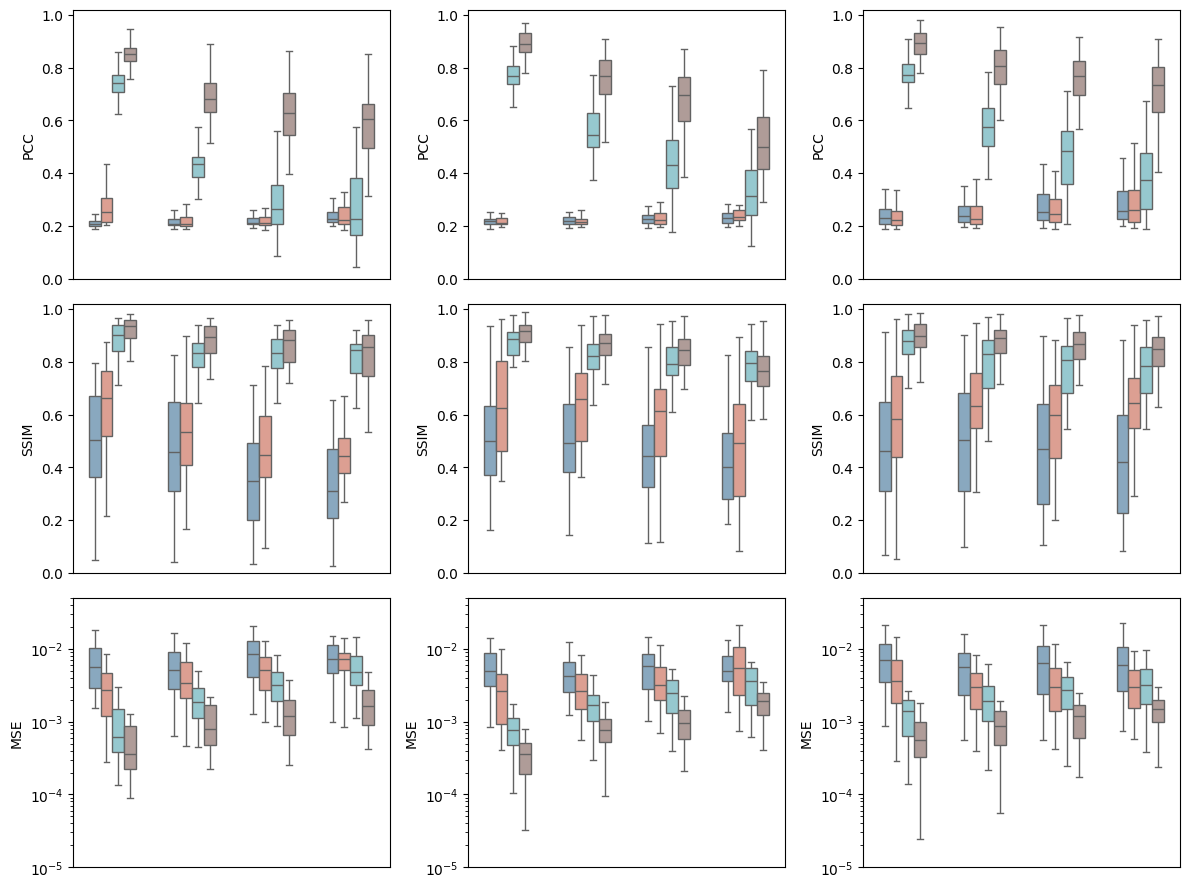

Saved final benchmark plot to ../../output/spot_benchmark


In [14]:
# [DEFINE] Plot styling and the shared comparison function
def plot_comp_seg(merge_df, metric, part, ax):
    
    spot_size_order = [50, 100, 150, 200]
    method_order = [method_labels[method] for method in methods]
    custom_palette = {
        method_labels[methods[0]]: '#80a9c8',
        method_labels[methods[1]]: '#e89786',
        method_labels[methods[2]]: '#8ccfd9',
        method_labels[methods[3]]: '#b39a94',
    }
    # Draw the method comparison.
    sns.boxplot(
        data=merge_df,
        x='Spot_size',
        y='Value',
        hue='Method',
        order=spot_size_order,
        hue_order=method_order,
        palette=[custom_palette[m] for m in method_order],
        width=0.6,
        fliersize=2,
        showfliers=False,
        ax=ax
    )
    # ax.set_title(f'{part}', fontsize=11, pad=8)
    # ax.set_xlabel('Spot Size', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.xaxis.set_visible(False)

    if metric == "PCC":
        ax.set_ylim(0, 1.02)
    elif metric == "SSIM":
        ax.set_ylim(0, 1.02)
    elif metric == "MSE":
        ax.set_ylim(1e-5, 0.05)
        ax.set_yscale('log')

    if ax.get_legend() is not None:
        ax.legend_.remove()
    ax.set_aspect('auto')

    
# [RUN] Plot the HVG comparison
fig, axes = plt.subplots(3, 3, figsize=(12, 9))

for i, part in enumerate(parts):
    for j, metric in enumerate(metrics):

        merge_df = get_merge_df(result_path, data_path, part, metric, spot_sizes, methods=methods)
        
        ax = axes[j, i]
        plot_comp_seg(merge_df, metric, part, ax)

plt.tight_layout()
plt.savefig(f"{output_dir}/spot_{gene_type}_{gene_num}.pdf", dpi=300)
plt.show()
print(f"Saved final benchmark plot to {output_dir}")


## 4. All evaluated genes

Repeat the comparison using every gene available in each method's metric table.

In [ ]:
# [RUN] Switch to all genes and plot the comparison
gene_type = "ALL"
gene_num = 50

fig, axes = plt.subplots(3, 3, figsize=(12, 9))

for i, part in enumerate(parts):
    for j, metric in enumerate(metrics):

        merge_df = get_merge_df(result_path, data_path, part, metric, spot_sizes, methods=methods)
        
        ax = axes[j, i]
        plot_comp_seg(merge_df, metric, part, ax)

plt.tight_layout()
plt.savefig(f"{output_dir}/spot_{gene_type}_{gene_num}.pdf", dpi=300)
plt.show()
print(f"Saved final benchmark plot to {output_dir}")


## 5. Outputs

Mean HVG tables are written to `output/spot_benchmark/HVG_mean/`. The HVG and all-gene figures are written to `output/spot_benchmark/` as PDF files.